## Notebook roadmap
This notebook reproduces **Figure 4** in the supplementary repo (migrated from old `figure_7.ipynb`).

Figure intent:
- aggregate seeded Fisher-information susceptibility curves for several system sizes,
- compare learnt susceptibility with Ferrenberg-Swendsen reference curves,
- build a finite-size-scaling collapse panel,
- export `figure_4.pdf/.svg` and a one-panel reference comparison `figure_4_true_cv.pdf/.svg`.


In [1]:
import os
import pickle

import numpy as np
import torch as pt

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from nestconf import Configurable
from typing import Tuple

from utils.aggregation import aggregate_seeded_results


# Common settings
Set typography and global plot defaults to match the migrated figure notebooks.


In [2]:
AXES_LINEWIDTH = 1.0
TICK_SIZE = 10
LABEL_SIZE = 8

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'text.latex.preamble': '\n'.join([
        r'\usepackage[semibold,sfdefault]{libertine}',
        r'\usepackage[libertine]{newtxmath}',
    ]),
    'axes.linewidth': AXES_LINEWIDTH,
})


# Load data
Load all localized Figure 4 inputs from `../data/figures/figure_4/` and deserialize experiment-config keys.


In [3]:
class Experiment(Configurable):
    """Schema for pickled experiment-configuration keys in Figure 4 payloads."""

    system_size: int = None
    bases_to_include: Tuple = None
    samples_per_point: int = 10000
    hidden_size: int = 64
    bootstrap: int = 1
    bootstrap_size: int = None
    use_deepset_encoding: bool = None
    take_every: int = None
    depth: int = None


figure_data_dir = '../data/figures/figure_4/main_distance_matrices'

with open(os.path.join(figure_data_dir, 'seeded_fisher_infos_dict.pickle'), 'rb') as handle:
    seeded_fisher_infos_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'seeded_fisher_stds_dict.pickle'), 'rb') as handle:
    seeded_fisher_stds_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'seeded_fisher_coords_dict.pickle'), 'rb') as handle:
    seeded_fisher_coords_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'coords_dict.pickle'), 'rb') as handle:
    coords_dict = pickle.load(handle)

with open('../data/figures/figure_4/fssa_system_size2temperatures.pickle', 'rb') as handle:
    system_size2temperatures = pickle.load(handle)
with open('../data/figures/figure_4/fssa_system_size2fisher_infos.pickle', 'rb') as handle:
    system_size2fisher_infos = pickle.load(handle)
with open('../data/figures/figure_4/fssa_system_size2hellinger_temperatures.pickle', 'rb') as handle:
    system_size2hellinger_temperatures = pickle.load(handle)
with open('../data/figures/figure_4/fssa_system_size2fisher_infos_hellinger.pickle', 'rb') as handle:
    system_size2fisher_infos_hellinger = pickle.load(handle)


## Build analysis payloads
Aggregate seed-level Fisher-information outputs into per-system-size susceptibility curves and errors.


In [4]:
def weighted_line_fit(*, x: np.ndarray, y: np.ndarray, yerr: np.ndarray):
    """Weighted fit of y = a x + b with weights 1 / yerr^2."""

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    w = 1.0 / np.maximum(yerr, 1e-12) ** 2
    A = np.stack([x, np.ones_like(x)], axis=1)
    WA = A * w[:, None]
    theta = np.linalg.solve(A.T @ WA, A.T @ (w * y))
    return float(theta[0]), float(theta[1])


NU = 1.0
T_C = 2.0 / np.log(1.0 + np.sqrt(2.0))
USE_REDUCED_T = True

TARGET_TAKE_EVERY = 4
TARGET_DELTA_MULTIPLIER = 1
TARGET_DIVERGENCE = 'hellinger'

available_widths = sorted({exp_config.hidden_size for exp_config in seeded_fisher_infos_dict})
if not available_widths:
    raise RuntimeError('No hidden_size values found in seeded_fisher_infos_dict')

# Keep the same legacy behavior: pick the first available width.
TARGET_WIDTH = available_widths[0]

selected_exp_configs = [
    exp_config
    for exp_config in seeded_fisher_infos_dict
    if (exp_config.hidden_size == TARGET_WIDTH and exp_config.take_every == TARGET_TAKE_EVERY)
]

unique_system_sizes = sorted({exp_config.system_size for exp_config in selected_exp_configs})
system_sizes_to_plot = tuple(unique_system_sizes[:4])

selected_exp_configs = [
    exp_config
    for exp_config in selected_exp_configs
    if exp_config.system_size in system_sizes_to_plot
]
selected_exp_configs = sorted(selected_exp_configs, key=lambda cfg: cfg.system_size)

payloads = []
for exp_config in selected_exp_configs:
    if TARGET_DELTA_MULTIPLIER not in seeded_fisher_infos_dict[exp_config][TARGET_DIVERGENCE]:
        continue

    temperatures = np.asarray(coords_dict[exp_config])[:, 0]
    delta = temperatures[1] - temperatures[0]

    fisher_infos_stack = list(
        seeded_fisher_infos_dict[exp_config][TARGET_DIVERGENCE][TARGET_DELTA_MULTIPLIER].values()
    )
    fisher_stds_stack = list(
        seeded_fisher_stds_dict[exp_config][TARGET_DIVERGENCE][TARGET_DELTA_MULTIPLIER].values()
    )
    fisher_coords_stack = list(
        seeded_fisher_coords_dict[exp_config][TARGET_DIVERGENCE][TARGET_DELTA_MULTIPLIER].values()
    )
    fisher_coords_stack = [pt.from_numpy(np.asarray(x)) for x in fisher_coords_stack]

    fisher_infos, fisher_stds, _, _ = aggregate_seeded_results(
        seeded_f_tensors=fisher_infos_stack,
        seeded_std_tensors=fisher_stds_stack,
        verbose=True,
        use_inverse_variance_weighting=True,
    )

    fisher_coords = fisher_coords_stack[0]
    T_pts = np.asarray(temperatures[fisher_coords])

    chi_f = fisher_infos / (delta ** 2)
    chi_f_err = fisher_stds / (delta ** 2)

    chi_f_np = chi_f.detach().cpu().numpy()
    chi_f_err_np = chi_f_err.detach().cpu().numpy()

    L = exp_config.system_size
    y_per_site = chi_f_np / (L ** 2)
    yerr_per_site = chi_f_err_np / (L ** 2)

    payloads.append({
        'exp_config': exp_config,
        'L': L,
        'delta': delta,
        'T_pts': T_pts,
        'chi_f': chi_f_np,
        'chi_f_err': chi_f_err_np,
        'y_per_site': y_per_site,
        'yerr_per_site': yerr_per_site,
    })

# Fit log-amplitude a from yc(L) = (chiF/L^2)|Tc ≈ a ln L + b
logL_list = []
yc_list = []
yc_err_list = []
for payload in payloads:
    T_pts = payload['T_pts']
    if (T_C < np.min(T_pts)) or (T_C > np.max(T_pts)):
        continue

    yc = float(np.interp(T_C, T_pts, payload['y_per_site']))
    yc_err = float(np.interp(T_C, T_pts, payload['yerr_per_site']))
    logL_list.append(np.log(payload['L']))
    yc_list.append(yc)
    yc_err_list.append(max(yc_err, 1e-12))

a_hat, b_hat = (0.0, 0.0)
if len(logL_list) >= 2:
    a_hat, b_hat = weighted_line_fit(
        x=np.asarray(logL_list),
        y=np.asarray(yc_list),
        yerr=np.asarray(yc_err_list),
    )


Aggregating results from 8 seeds.
Aggregating results from 8 seeds.
Aggregating results from 8 seeds.
Aggregating results from 8 seeds.


## Save FSSA arrays
Persist processed arrays used in downstream FSSA tooling.


In [5]:
system_sizes = np.asarray([payload['L'] for payload in payloads])
control_parameters = np.asarray([payload['T_pts'] for payload in payloads])
measurements = np.asarray([payload['y_per_site'] for payload in payloads])
stds = np.asarray([payload['yerr_per_site'] for payload in payloads])

if control_parameters.size:
    control_parameters = np.mean(control_parameters, axis=0)

np.save('../data/figures/figure_4/fssa_system_sizes.npy', system_sizes)
np.save('../data/figures/figure_4/fssa_control_parameters.npy', control_parameters)
np.save('../data/figures/figure_4/fssa_measurements.npy', measurements)
np.save('../data/figures/figure_4/fssa_stds.npy', stds)


# Build and export figures
Generate both manuscript outputs:
- `figure_4.pdf/.svg`: two-panel susceptibility + collapse,
- `figure_4_true_cv.pdf/.svg`: one-panel learnt vs true-$C_V$ comparison.


/var/folders/xs/ft410byd4qb226jqk7qd4mq40000gp/T/ipykernel_31603/478085367.py:141: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma')


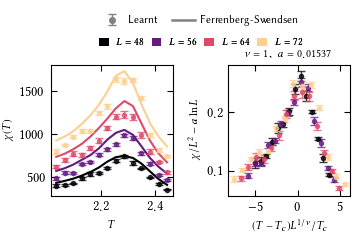

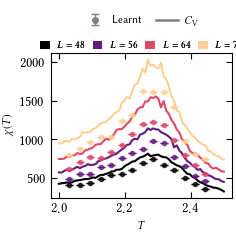

In [6]:
def style_axes(ax, *, xlabel: str, ylabel: str, axes_linewidth: float):
    """Apply consistent axis labels/ticks/spines for manuscript-style plots."""

    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.tick_params(
        axis='both',
        which='both',
        direction='in',
        labelsize=TICK_SIZE,
        width=axes_linewidth,
        size=4,
        top=True,
        right=True,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(axes_linewidth)


def add_combined_legends(legend_ax, *, l_to_color: dict, legend_label_2: str):
    """Add style legend + system-size legend in the dedicated top legend row."""

    legend_ax.axis('off')

    err_proxy = legend_ax.errorbar(
        [0], [0], yerr=[1.0], fmt='o', color='0.5', linestyle='',
        markersize=4, capsize=3, elinewidth=1, capthick=1,
    )
    theory_proxy = Line2D([0], [0], linestyle='-', linewidth=1.8, color='0.5')

    style_leg = legend_ax.legend(
        handles=[err_proxy, theory_proxy],
        labels=['Learnt', legend_label_2],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.95),
        ncol=2,
        frameon=False,
        fontsize=LABEL_SIZE,
        handletextpad=0.6,
        columnspacing=1.2,
    )
    legend_ax.add_artist(style_leg)

    patch_handles = [
        Patch(facecolor=l_to_color[L], edgecolor='none', label=fr'$L={L}$')
        for L in system_sizes_to_plot
        if L in l_to_color
    ]
    legend_L = legend_ax.legend(
        handles=patch_handles,
        loc='upper center',
        bbox_to_anchor=(0.50, 0.25),
        ncol=min(4, len(patch_handles)),
        frameon=False,
        fontsize=LABEL_SIZE - 1,
        columnspacing=0.8,
        handlelength=1.0,
        handleheight=0.8,
        borderpad=0.2,
        labelspacing=0.3,
    )
    legend_ax.add_artist(legend_L)

    # Remove proxy artists so they do not appear on the canvas itself.
    data_line, cap_lines, bar_cols = err_proxy.lines
    data_line.remove()
    for cap in cap_lines:
        cap.remove()
    for barcol in bar_cols:
        barcol.remove()


def plot_susceptibility_curves(ax, *, l_to_color: dict, use_true_cv: bool):
    """Plot learnt susceptibility with error bars and reference theory curve per system size."""

    for payload in payloads:
        L = payload['L']
        color = l_to_color[L]

        yerr = payload['chi_f_err'] / (L ** 2) if use_true_cv else payload['chi_f_err']
        ax.errorbar(
            payload['T_pts'],
            payload['chi_f'],
            yerr=yerr,
            marker='o',
            linestyle='',
            markersize=3,
            alpha=0.75,
            capsize=3,
            elinewidth=1,
            capthick=1,
            color=color,
        )

        if use_true_cv:
            if L in system_size2temperatures and L in system_size2fisher_infos:
                T_theory = np.asarray(system_size2temperatures[L])
                chi_theory = 8.0 * np.asarray(system_size2fisher_infos[L])
                ax.plot(T_theory, chi_theory, linestyle='-', linewidth=1.5, color=color)
        else:
            if (L in system_size2hellinger_temperatures) and (TARGET_TAKE_EVERY in system_size2hellinger_temperatures[L]):
                T_theory = np.asarray(system_size2hellinger_temperatures[L][TARGET_TAKE_EVERY])
                chi_theory = np.asarray(system_size2fisher_infos_hellinger[L][TARGET_TAKE_EVERY])
                ax.plot(T_theory, chi_theory, linestyle='-', linewidth=1.5, color=color)


def plot_fss_collapse(ax, *, l_to_color: dict):
    """Plot log-corrected finite-size-scaling collapse used in manuscript Figure 4."""

    for payload in payloads:
        L = float(payload['L'])
        color = l_to_color[payload['L']]

        T_pts = payload['T_pts']
        y = payload['y_per_site']
        yerr = payload['yerr_per_site']

        if USE_REDUCED_T:
            x_scaled = ((T_pts - T_C) / T_C) * (L ** (1.0 / NU))
        else:
            x_scaled = (T_pts - T_C) * (L ** (1.0 / NU))

        y_scaled = y - a_hat * np.log(L)

        ax.errorbar(
            x_scaled,
            y_scaled,
            yerr=yerr,
            marker='o',
            linestyle='',
            markersize=3,
            alpha=0.75,
            capsize=3,
            elinewidth=1,
            capthick=1,
            color=color,
        )


# Shared color palette by system size
cmap = cm.get_cmap('magma')
colors = cmap(np.linspace(0.0, 0.9, max(len(payloads), 1)))
L2color = {payload['L']: colors[idx] for idx, payload in enumerate(payloads)}

# Figure 4: susceptibility + collapse
fig = plt.figure(figsize=(9 / 2.54, 6 / 2.54), constrained_layout=True)
grid_spec = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[0.28, 1.0], width_ratios=[1.0, 1.0])
legend_ax = fig.add_subplot(grid_spec[0, :])
susc_ax = fig.add_subplot(grid_spec[1, 0])
fssa_ax = fig.add_subplot(grid_spec[1, 1])

plot_susceptibility_curves(susc_ax, l_to_color=L2color, use_true_cv=False)
plot_fss_collapse(fssa_ax, l_to_color=L2color)

if USE_REDUCED_T:
    x_label = r"$(T-T_c)L^{1/\nu}/T_c$"
else:
    x_label = r"$(T-T_c)L^{1/\nu}$"

style_axes(susc_ax, xlabel=r'$T$', ylabel=r'$\chi(T)$', axes_linewidth=0.8)
style_axes(
    fssa_ax,
    xlabel=x_label,
    ylabel=r'$\chi/L^2 - a\ln L$',
    axes_linewidth=0.8,
)

fssa_ax.set_title(rf'$\nu={NU:.0f},\ a={a_hat:.4g}$', fontsize=LABEL_SIZE)

add_combined_legends(legend_ax, l_to_color=L2color, legend_label_2='Ferrenberg-Swendsen')

fig.savefig('./figure_4.pdf', bbox_inches='tight', pad_inches=0.00)
fig.savefig('./figure_4.svg', bbox_inches='tight', pad_inches=0.00)

# Figure 4 true-CV comparison: susceptibility only
fig_true = plt.figure(figsize=(6 / 2.54, 6 / 2.54), constrained_layout=True)
grid_true = fig_true.add_gridspec(nrows=2, ncols=1, height_ratios=[0.28, 1.0], width_ratios=[1.0])
legend_ax_true = fig_true.add_subplot(grid_true[0, :])
susc_ax_true = fig_true.add_subplot(grid_true[1, 0])

plot_susceptibility_curves(susc_ax_true, l_to_color=L2color, use_true_cv=True)
style_axes(susc_ax_true, xlabel=r'$T$', ylabel=r'$\chi(T)$', axes_linewidth=0.8)
add_combined_legends(legend_ax_true, l_to_color=L2color, legend_label_2=r'$C_{\rm V}$')

fig_true.savefig('./figure_9.pdf', bbox_inches='tight', pad_inches=0.00)
fig_true.savefig('./figure_9.svg', bbox_inches='tight', pad_inches=0.00)
